# Plot Feature v Initiation Storm Densities - MRMS (2021-2024)

C:\Users\msmillan\AppData\Local\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
C:\Users\msmillan\AppData\Local\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,


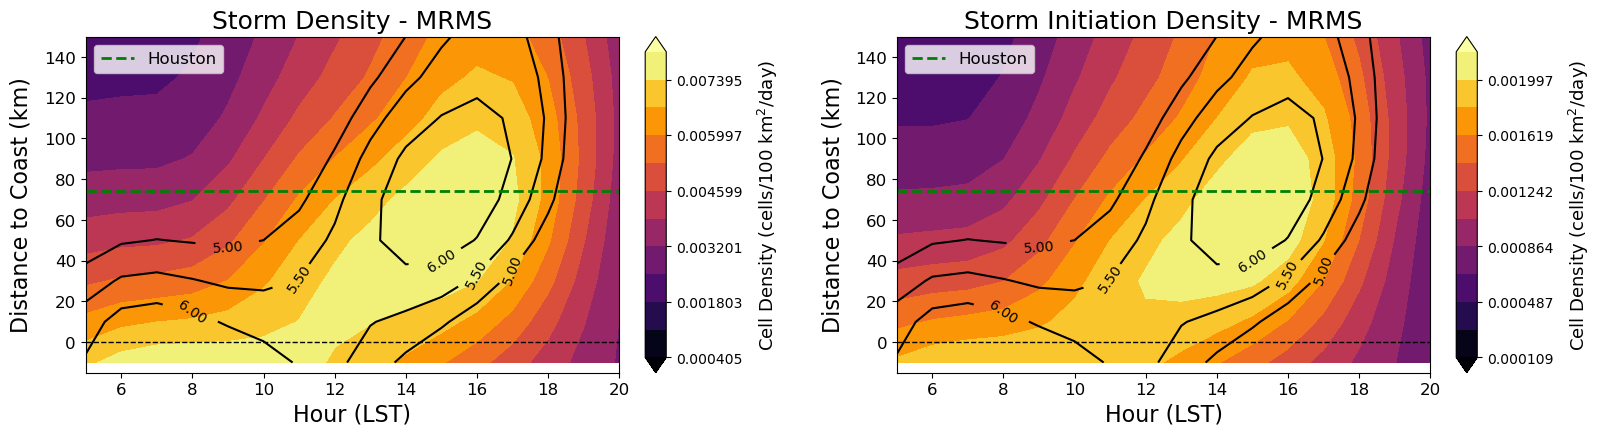

Saved: Plot_Directory\MRMS_stormdensity_initiationdensity_side_by_side.png


In [1]:
# -*- coding: utf-8 -*-

import xarray as xr
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# ------------------------------------------------------------
# Plot style
# ------------------------------------------------------------
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 16,
    'figure.titlesize': 16
})

# ------------------------------------------------------------
# FILES
# ------------------------------------------------------------
f_mrms_all  = "Counts_and_ArealDensities_BLACK_ALLFEATURES_2021_2024_Smoothed.nc"
f_mrms_init = "Counts_and_ArealDensities_BLACK_INITONLY_2021_2024_Smoothed.nc"

# ------------------------------------------------------------
# OUTPUT
# ------------------------------------------------------------
outdir = "Plot_Directory"
os.makedirs(outdir, exist_ok=True)
outfile_png = os.path.join(
    outdir,
    "MRMS_stormdensity_initiationdensity_side_by_side.png"
)

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def subset_distance_robust(ds, dmin=-15, dmax=155):
    dist = ds["distance_km"].values
    if dist[0] < dist[-1]:
        return ds.sel(distance_km=slice(dmin, dmax))
    else:
        return ds.sel(distance_km=slice(dmax, dmin))

def load_density_and_rain(ds):
    if "areal_density_per_100km2_day_smoothed" not in ds.variables:
        raise KeyError("Missing 'areal_density_per_100km2_day_smoothed' in NetCDF.")

    fd = ds["areal_density_per_100km2_day_smoothed"].values
    hours = ds["hour"].values
    dist_km = ds["distance_km"].values

    if "raw_rainfall_binned_smoothed" in ds.variables:
        rr = ds["raw_rainfall_binned_smoothed"].values
    elif "raw_rainfall_binned" in ds.variables:
        rr = ds["raw_rainfall_binned"].values
    else:
        raise KeyError(
            "Could not find rainfall field in the NetCDF "
            "(expected raw_rainfall_binned_smoothed or raw_rainfall_binned)."
        )

    return fd, rr, hours, dist_km

def plot_panel(ax, fd, rr, hours, dist_km, dlevels, rlevels, title):
    cf = ax.contourf(
        hours, dist_km, fd,
        levels=dlevels,
        cmap="inferno",
        extend="both"
    )

    cs = ax.contour(
        hours, dist_km, rr,
        levels=rlevels,
        colors="black",
        linewidths=1.5
    )
    ax.clabel(cs, fmt="%.2f", fontsize=10)

    ax.axhline(0, color="k", linestyle="--", linewidth=1)
    ax.axhline(74.3, color="g", linestyle="--", linewidth=2, label="Houston")

    ax.set_xlim(5, 20)
    ax.set_ylim(-15, 150)
    ax.set_xlabel("Hour (LST)")
    ax.set_title(title)
    ax.legend(loc="upper left", frameon=True, fontsize=12)

    return cf

# ------------------------------------------------------------
# LOAD DATASETS
# ------------------------------------------------------------
ds_mrms_all  = subset_distance_robust(xr.open_dataset(f_mrms_all))
ds_mrms_init = subset_distance_robust(xr.open_dataset(f_mrms_init))

fd_all, rr_all, hours_all, dist_all = load_density_and_rain(ds_mrms_all)
fd_init, rr_init, hours_init, dist_init = load_density_and_rain(ds_mrms_init)

# ------------------------------------------------------------
# LEVELS
# ------------------------------------------------------------
fdmax_all = np.nanmax(fd_all)
dlevels_all = (
    np.linspace(0.05 * fdmax_all, fdmax_all, 12)
    if np.isfinite(fdmax_all) and fdmax_all > 0
    else np.linspace(0, 1, 12)
)

fdmax_init = np.nanmax(fd_init)
dlevels_init = (
    np.linspace(0.05 * fdmax_init, fdmax_init, 12)
    if np.isfinite(fdmax_init) and fdmax_init > 0
    else np.linspace(0, 1, 12)
)

rlevels_mrms = [5.0, 5.5, 6.0]

# ------------------------------------------------------------
# FIGURE LAYOUT
# ------------------------------------------------------------
# Similar approach to the previous corrected script:
# use a wider figure + fixed box aspect for each panel
fig = plt.figure(figsize=(16.2, 5.7))
gs = GridSpec(1, 2, figure=fig, wspace=0.52)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

# Make the Hovmöller panel shape similar to the previous script
ax1.set_box_aspect(0.63)
ax2.set_box_aspect(0.63)

# ------------------------------------------------------------
# PLOT PANELS
# ------------------------------------------------------------
cf1 = plot_panel(
    ax1,
    fd_all, rr_all, hours_all, dist_all,
    dlevels=dlevels_all,
    rlevels=rlevels_mrms,
    title="Storm Density - MRMS"
)

cf2 = plot_panel(
    ax2,
    fd_init, rr_init, hours_init, dist_init,
    dlevels=dlevels_init,
    rlevels=rlevels_mrms,
    title="Storm Initiation Density - MRMS"
)

ax1.set_ylabel("Distance to Coast (km)", labelpad=8)
ax2.set_ylabel("Distance to Coast (km)", labelpad=8)

# ------------------------------------------------------------
# LAYOUT
# ------------------------------------------------------------
fig.subplots_adjust(left=0.07, right=0.90, top=0.90, bottom=0.12, wspace=0.52)

# ------------------------------------------------------------
# MANUAL COLORBAR AXES
# ------------------------------------------------------------
p1 = ax1.get_position()
p2 = ax2.get_position()

cbw = 0.013
gap = 0.016

# left colorbar
cax1 = fig.add_axes([p1.x1 + gap, p1.y0, cbw, p1.height])
cbar1 = fig.colorbar(cf1, cax=cax1)
cbar1.set_label("Cell Density (cells/100 km$^2$/day)", fontsize=13, labelpad=10)
cbar1.ax.tick_params(labelsize=10)

# right colorbar
cax2 = fig.add_axes([p2.x1 + gap, p2.y0, cbw, p2.height])
cbar2 = fig.colorbar(cf2, cax=cax2)
cbar2.set_label("Cell Density (cells/100 km$^2$/day)", fontsize=13, labelpad=10)
cbar2.ax.tick_params(labelsize=10)

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------
plt.savefig(outfile_png, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", outfile_png)